# Phase 3: Exploratory Data Analysis (EDA) and Data Quality

## Objective
To explore the `bank_marketing` dataset, identify data quality issues, understand target distribution, and analyze relationships between features and the target variable (`y`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
%matplotlib inline

## 1. Data Loading

In [2]:
df = pd.read_csv('../data/raw/bank_marketing.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day_of_week,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,NaN,5,may,261,1,-1,0,NaN,no
1,44,technician,single,secondary,no,29,yes,no,NaN,5,may,151,1,-1,0,NaN,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,NaN,5,may,76,1,-1,0,NaN,no
3,47,blue-collar,married,NaN,no,1506,yes,no,NaN,5,may,92,1,-1,0,NaN,no
4,33,NaN,single,NaN,no,1,no,no,NaN,5,may,198,1,-1,0,NaN,no


## 2. Data Quality & Missing Values

In [3]:
# Check missing values
missing = df.isnull().sum()
print("Missing Values:\n", missing[missing > 0])

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Unknown values analysis
for col in df.select_dtypes(include='object').columns:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"Column '{col}' has {unknown_count} 'unknown' values ({(unknown_count/len(df))*100:.2f}%)")

Missing Values:
 job            288
education     1857
contact      13020
poutcome     36959
dtype: int64

Duplicate rows: 0


## 3. Target Variable Analysis

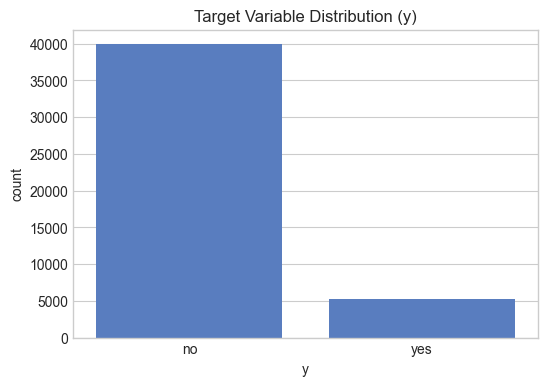

y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='y', data=df)
plt.title('Target Variable Distribution (y)')
plt.savefig('../reports/figures/target_distribution.png')
plt.show()

print(df['y'].value_counts(normalize=True) * 100)

## 4. Numerical Variables Analysis

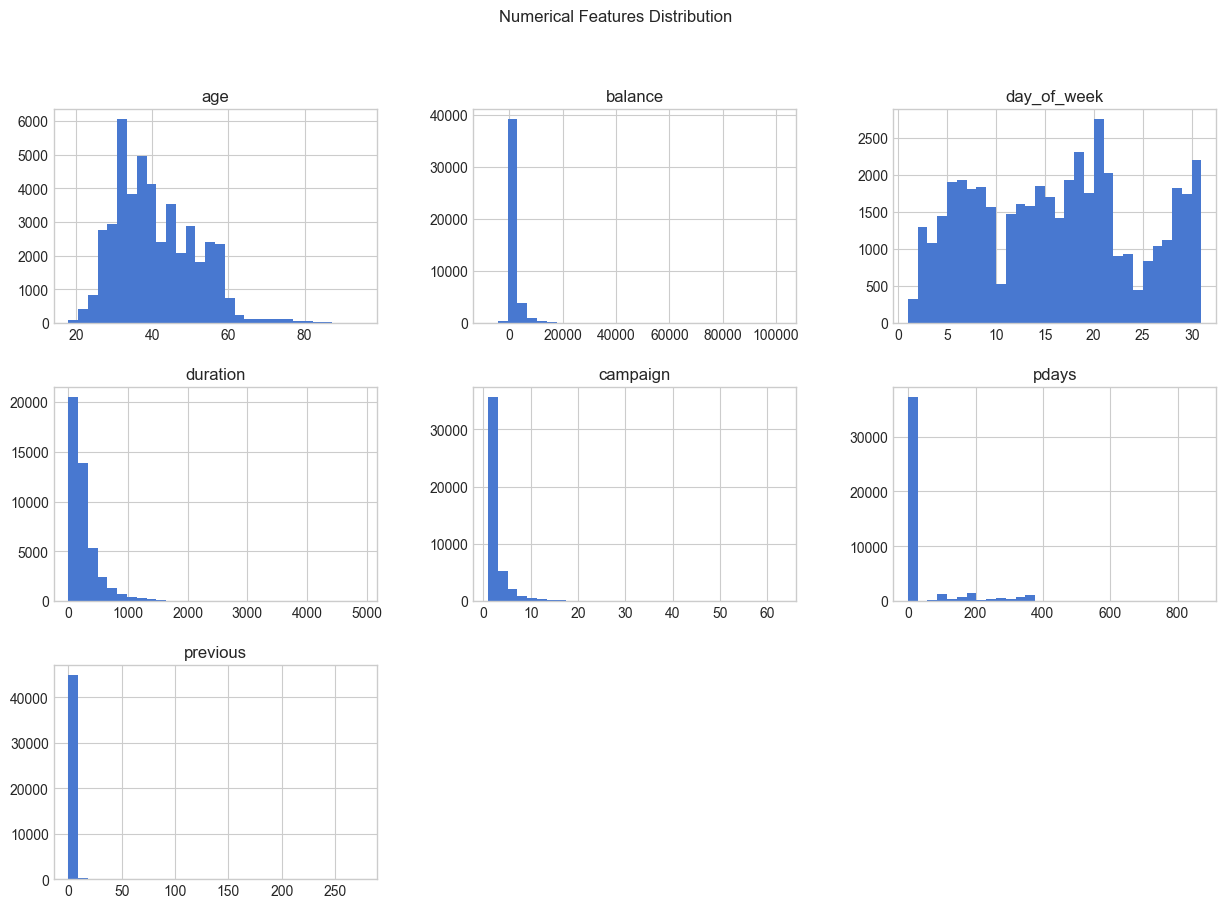

In [5]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Plot distributions
df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Numerical Features Distribution')
plt.savefig('../reports/figures/numerical_distribution.png')
plt.show()

## 5. Categorical Variables Analysis

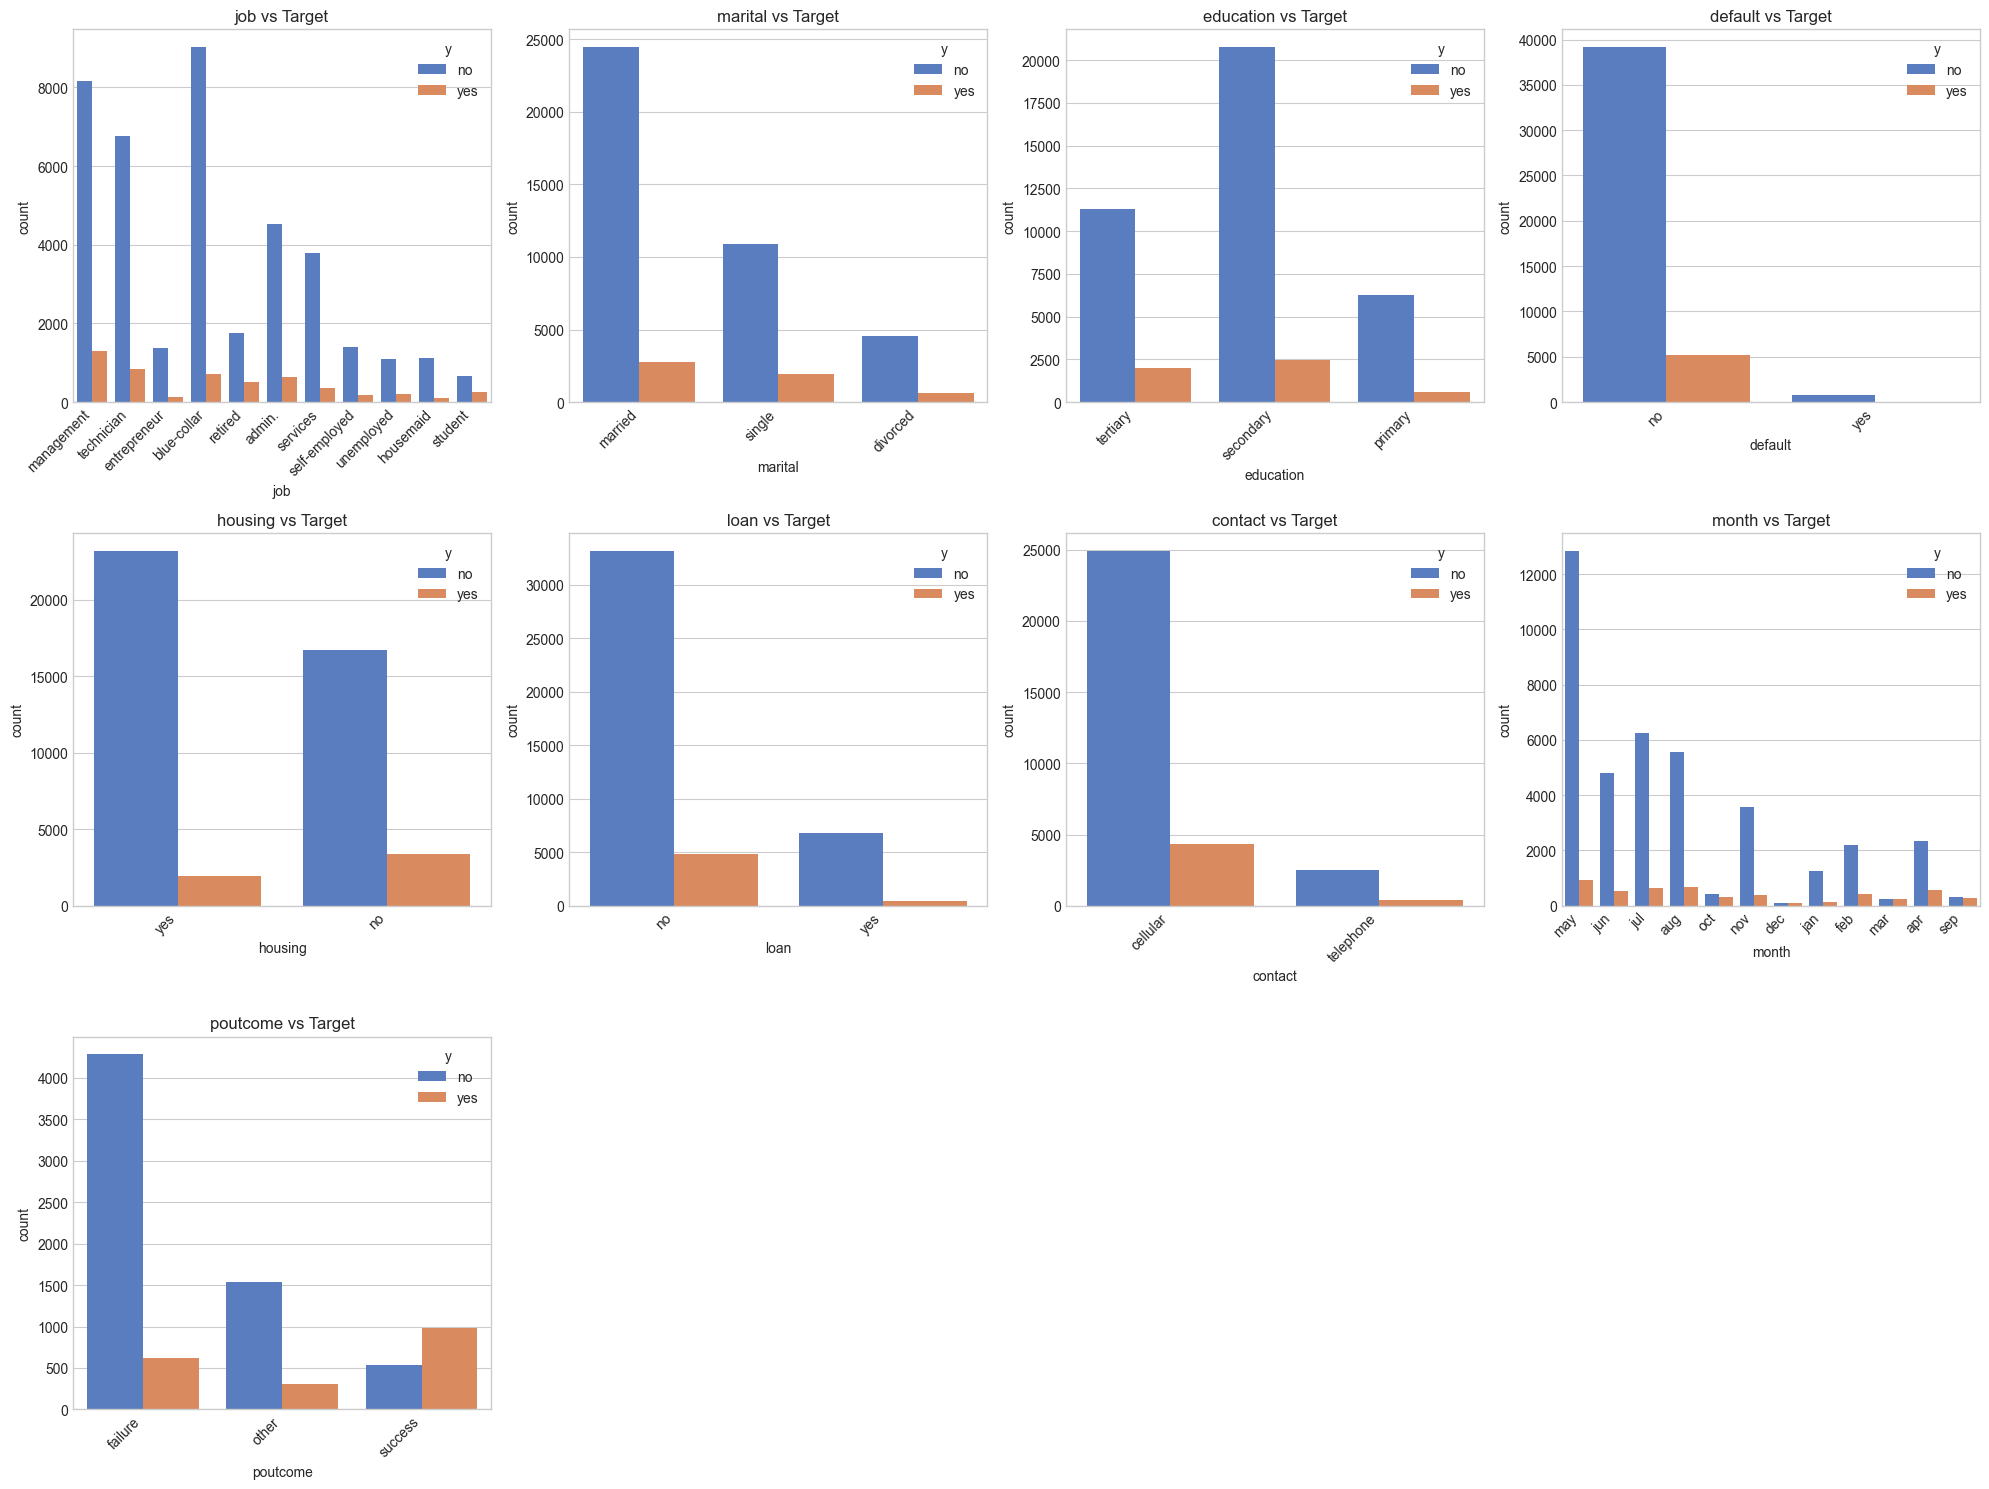

In [6]:
cat_cols = df.select_dtypes(include='object').columns.drop('y').tolist()

plt.figure(figsize=(20, 15))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 4, i)
    sns.countplot(x=col, hue='y', data=df)
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{col} vs Target')
plt.tight_layout()
plt.savefig('../reports/figures/categorical_vs_target.png')
plt.show()

## 6. Leakage Analysis

Analyzing 'duration' feature which is highly correlated with target and only known after the call:


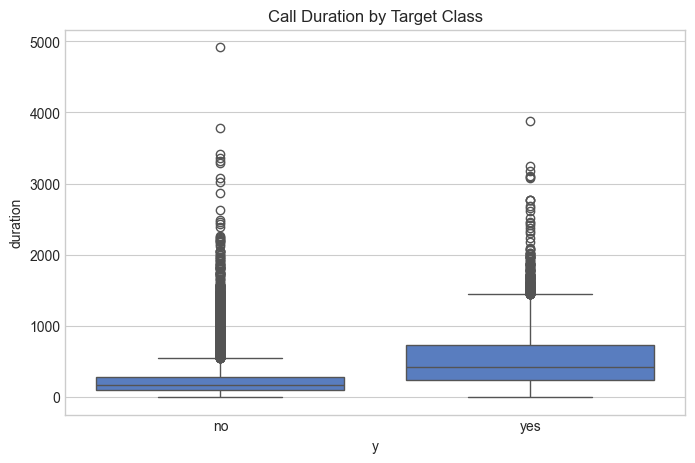

Note: 'duration' should be removed before modelling to prevent target leakage.


In [7]:
print("Analyzing 'duration' feature which is highly correlated with target and only known after the call:")
plt.figure(figsize=(8, 5))
sns.boxplot(x='y', y='duration', data=df)
plt.title('Call Duration by Target Class')
plt.savefig('../reports/figures/duration_vs_target.png')
plt.show()

print("Note: 'duration' should be removed before modelling to prevent target leakage.")

## Key Findings
1. **Imbalance**: The target `y` is highly imbalanced (~88% 'no', ~12% 'yes').
2. **Missing/Unknown**: Variables like `poutcome`, `contact`, `education`, and `job` have a significant number of 'unknown' or missing values.
3. **Leakage**: The `duration` variable must be dropped because it directly leaks the outcome (duration=0 implies 'no').
4. **Distributions**: Most numerical variables like `balance`, `pdays`, and `campaign` are highly right-skewed.
